# Hierarchical Clustering Notes

---

## Why Hierarchical Clustering?
- K-Means works well only for **spherical clusters**.
- Struggles with **complex shapes** (like concentric circles).
- Sensitive to **noise and outliers**.
- Hierarchical clustering provides a more **flexible, visual approach**.

---

## Types of Hierarchical Clustering
1. **Agglomerative (Bottom-Up)**  
   - Start: each point is its own cluster.  
   - Iteratively merge the closest clusters.  
   - Continue until one cluster remains.  
   - Most commonly used.

2. **Divisive (Top-Down)**  
   - Start: all points in one cluster.  
   - Iteratively split into smaller clusters.  
   - Less commonly used.

---

## Dendrogram
- A **tree-like diagram** showing how clusters merge step by step.  
- Cutting the dendrogram at different heights gives different numbers of clusters.  
- The **longest vertical line without crossing horizontal cuts** indicates the optimal number of clusters.

---

## Working of Agglomerative Clustering
1. Initialization → each point = separate cluster.  
2. Find the **closest clusters** (based on distance metric).  
3. Merge them into one cluster.  
4. Record the merge in the dendrogram.  
5. Repeat until stopping criterion (e.g., desired number of clusters).  

---

## Distance Metrics (Linkage Criteria)
| Method        | Description                                | Pros                          | Cons                          |
|---------------|--------------------------------------------|-------------------------------|-------------------------------|
| Single Link   | Closest points between clusters             | Handles elongated clusters    | Sensitive to noise (chaining) |
| Complete Link | Farthest points between clusters            | Robust to noise               | May split large clusters      |
| Average Link  | Average distance between all pairs          | Balanced approach             | Moderate sensitivity          |
| Ward’s Method | Minimizes variance within clusters          | Compact, spherical clusters   | Computationally intensive     |

---

## Examples
- **Single Link** → good for irregular shapes, but chaining effect.  
- **Complete Link** → avoids chaining, but can break big clusters.  
- **Average Link** → compromise between the two.  
- **Ward’s Method** → best for compact, spherical clusters.

---

## Benefits
- No need to pre-specify number of clusters strictly.  
- Provides a **visual tool (dendrogram)** for decision-making.  
- Works with different shapes and densities (depending on linkage).  
- Intuitive for small to medium datasets.

---

## Limitations
- Computationally heavy → requires storing a **proximity matrix**.  
- Not suitable for **very large datasets** (millions of points).  
- Sensitive to choice of **distance metric** and **linkage method**.  
- Divisive clustering is rarely used in practice.

---

## Practical Implementation
- Use **Agglomerative Clustering** in Python (`sklearn.cluster.AgglomerativeClustering`).  
- Plot dendrograms with `scipy.cluster.hierarchy.dendrogram`.  
- Cut dendrogram at optimal height to extract cluster labels.  

# Distance Matrix for 5 Points


|       | P1   | P2   | P3   | P4   | P5   |
|-------|------|------|------|------|------|
| **P1** | 0    | 1.0  | 9.90 | 10.63| 11.31|
| **P2** | 1.0  | 0    | 9.22 | 10.0 | 10.63|
| **P3** | 9.90 | 9.22 | 0    | 1.0  | 1.41 |
| **P4** | 10.63| 10.0 | 1.0  | 0    | 1.0  |
| **P5** | 11.31| 10.63| 1.41 | 1.0  | 0    |

---

#  Step-Wise Cluster Formation

| Cut Level   | Clusters Formed             | Explanation                                |
|-------------|-----------------------------|--------------------------------------------|
| 5 clusters  | {P1}, {P2}, {P3}, {P4}, {P5} | Start: each point is its own cluster        |
| 4 clusters  | {P1}, {P2}, {P3,P4}, {P5}   | Closest pair → P3 & P4 merge                |
| 3 clusters  | {P1}, {P2}, {P3,P4,P5}      | Next closest → {P3,P4} merges with P5       |
| 2 clusters  | {P1,P2}, {P3,P4,P5}         | P1 & P2 merge together                      |
| 1 cluster   | {P1,P2,P3,P4,P5}            | Finally, both big clusters merge            |


# Theory: How the Distance Matrix Drives Clustering

---

## Understanding the Distance Matrix
- The table shows **pairwise Euclidean distances** between all points (P1–P5).
- Small values = points are close together → likely to merge early.
- Large values = points are far apart → merge later in the process.

---

## Step-by-Step Process
1. **Initialization**  
   - Each point starts as its own cluster (5 clusters).

2. **Find the smallest distance**  
   - In the matrix, the smallest non-zero value is between P3 and P4 (distance = 1.0).  
   - So, P3 and P4 merge first.

3. **Update clusters**  
   - Now we treat {P3,P4} as one cluster.  
   - Next closest distance is between {P3,P4} and P5 (≈ 1.0–1.41).  
   - So, P5 joins them → cluster {P3,P4,P5}.

4. **Merge other close points**  
   - P1 and P2 are close (distance = 1.0).  
   - They merge into {P1,P2}.

5. **Final merge**  
   - Now we have two clusters: {P1,P2} and {P3,P4,P5}.  
   - The distance between them is large (~9–11).  
   - At this stage, merging them produces **one big cluster**.

---

## Cutting the Dendrogram
- If we cut the dendrogram **low** → 5 clusters (all separate).  
- Cut at **medium height (~2)** → 3 clusters ({P1}, {P2}, {P3,P4,P5}).  
- Cut at **higher height (~9)** → 2 clusters ({P1,P2}, {P3,P4,P5}).  
- Cut at the **highest height (~11)** → 1 cluster (all merged).

---

## Key Insight
- Hierarchical clustering **always ends in one big cluster** if you let it run fully.  
- The **useful step** is deciding **where to cut** the dendrogram.  
- Cutting at the right height gives the **meaningful number of clusters** for your dataset.


In [1]:
# --------------------------------------------
# Hierarchical Clustering Example
# --------------------------------------------

# Step 1: Importing essential libraries
import numpy as np              # For numerical operations and arrays
import matplotlib.pyplot as plt # For plotting graphs and dendrograms
import pandas as pd             # For handling datasets (CSV, DataFrame)

# At this stage:
# - NumPy will help with mathematical calculations
# - Matplotlib will help us visualize clusters and dendrograms
# - Pandas will load and manage the dataset we want to cluster


In [2]:
# --------------------------------------------
# Step 2: Importing the dataset for clustering
# --------------------------------------------

# Load the dataset 'Mall_Customers.csv' into a pandas DataFrame
dataset = pd.read_csv('Mall_Customers.csv')

# Select the features (columns) we want to use for clustering
# iloc[:, [3, 4]] → picks columns by index:
#   Column 3 → Annual Income (k$)
#   Column 4 → Spending Score (1–100)
# .values → converts the DataFrame slice into a NumPy array

X = dataset.iloc[:, [3, 4]].values

# At this stage:
# - 'dataset' holds the full customer data (ID, Gender, Age, Income, Score).
# - 'X' contains only the two features we’ll use for clustering.
#   Each row in X = [Annual Income, Spending Score].


In [4]:
dataset.head(5)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


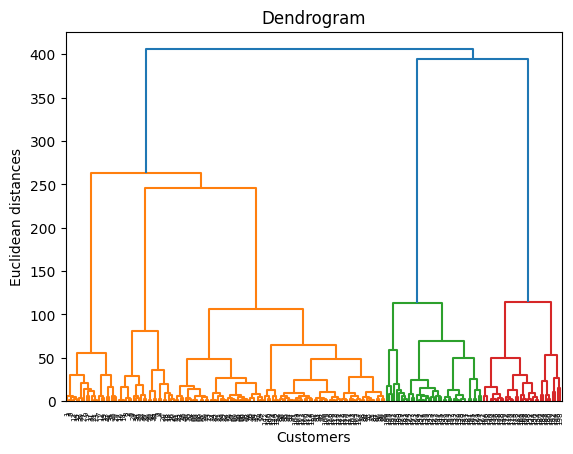

In [3]:
# --------------------------------------------
# Step 3: Using the dendrogram to find optimal clusters
# --------------------------------------------

# Import the hierarchical clustering tools from SciPy
import scipy.cluster.hierarchy as sch

# Create the linkage matrix using Ward's method
# - 'X' is our feature matrix (Annual Income, Spending Score)
# - 'ward' minimizes variance within clusters, producing compact clusters
linkage_matrix = sch.linkage(X, method='ward')

# Plot the dendrogram
# - Shows how clusters are merged step by step
# - The vertical axis = Euclidean distance between merged clusters
# - Cutting the dendrogram at a chosen height gives the number of clusters
dendrogram = sch.dendrogram(linkage_matrix)

# Add plot labels and title for clarity
plt.title('Dendrogram')
plt.xlabel('Customers')           # Each leaf = one customer
plt.ylabel('Euclidean distances') # Height = distance between clusters

# Display the dendrogram
plt.show()

# Cutting Clusters in a Dendrogram

---

## What is "Cutting" the Dendrogram?
- A dendrogram shows how clusters are merged step by step.
- The vertical axis = distance (similarity measure).
- By drawing a **horizontal cut line** across the dendrogram, we decide how many clusters to keep.

---

## Step-by-Step Theory

1. **Build the dendrogram**  
   - Start with each point as its own cluster.  
   - Merge clusters step by step based on chosen linkage (Ward, Single, Complete, Average).  
   - Record merges and distances.

2. **Observe vertical distances**  
   - Long vertical lines = large jumps in distance between merges.  
   - These indicate natural separation between clusters.

3. **Draw a horizontal cut line**  
   - Place the line at a height just before a large vertical jump.  
   - Every branch below the line is considered a separate cluster.

4. **Count the clusters**  
   - The number of vertical lines intersected by the cut line = number of clusters.  
   - Example: Cutting at height = 150 may give 5 clusters.

5. **Interpret clusters**  
   - Each cluster groups points that are closer together than the cut threshold.  
   - Different cut heights give different numbers of clusters (flexibility).

---

## Easy Analogy
Think of the dendrogram as a **family tree**:
- Cutting the tree at a certain level shows how many “families” (clusters) exist.  
- Higher cut = fewer, bigger families.  
- Lower cut = more, smaller families.

---

##  Key Point
The **optimal cut height** is usually chosen at the **largest vertical gap** in the dendrogram (without crossing horizontal lines).  
This ensures clusters are well separated and meaningful.


In [5]:
# --------------------------------------------
# Step 4: Training the Hierarchical Clustering model
# --------------------------------------------

# Import Agglomerative Clustering from scikit-learn
from sklearn.cluster import AgglomerativeClustering

# Create the Hierarchical Clustering model
# Parameters:
# - n_clusters = 5 → we want to form 5 clusters (chosen from dendrogram)
# - metric = 'euclidean' → distance metric used to measure closeness
# - linkage = 'ward' → minimizes variance within clusters, producing compact clusters

hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
# Fit the model to our dataset (X) and predict cluster labels
# Each customer gets assigned to one of the 5 clusters
y_hc = hc.fit_predict(X)

# At this stage:
# - 'hc' is our trained clustering model
# - 'y_hc' is an array of cluster labels (0, 1, 2, 3, 4) for each customer

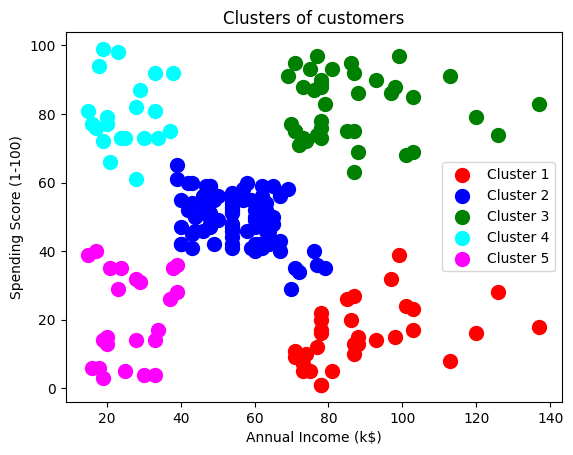

In [6]:
# --------------------------------------------
# Step 5: Visualising the clusters
# --------------------------------------------

# Plot each cluster separately with different colors
# X[y_hc == k, 0] → selects Annual Income values for cluster k
# X[y_hc == k, 1] → selects Spending Score values for cluster k
# s = 100 → sets marker size
# c = 'color' → sets marker color
# label = 'Cluster n' → legend label for each cluster

plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s=100, c='red',     label='Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s=100, c='blue',    label='Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s=100, c='green',   label='Cluster 3')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s=100, c='cyan',    label='Cluster 4')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s=100, c='magenta', label='Cluster 5')

# Add plot title and axis labels
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

# Show legend to identify clusters
plt.legend()

# Display the scatter plot
plt.show()

# At this stage:
# - Each cluster is shown in a different color.
# - X-axis = Annual Income, Y-axis = Spending Score.
# - Helps us visually interpret customer segments.
